<a href="https://colab.research.google.com/github/AaronGrace978/Automata/blob/main/notebooks/diatom_nca_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AaronGrace978/Automata/blob/main/notebooks/diatom_nca_colab.ipynb)

# 🦠 Diatom NCA — Morphogenesis in Your Browser

**One shared local rule → a glass diatom grows from a single cell. Cut it, it heals. Play sound, it bends.**

Run top to bottom (Runtime → Run all). A GPU helps but everything runs on CPU too.

In [ ]:
# ── 0. Setup ─────────────────────────────────────────────
import sys, subprocess
try:
    import torch
    print('torch', torch.__version__)
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'torch', 'matplotlib', 'scipy', 'pillow'], check=True)
    import torch

# Make `nca/` importable: local checkout first, else clone from GitHub.
import os, importlib.util
def _has_nca(): return importlib.util.find_spec('nca') is not None
for cand in [os.getcwd(), os.path.dirname(os.getcwd()), '/content/Automata']:
    if os.path.isdir(os.path.join(cand, 'nca')) and cand not in sys.path:
        sys.path.insert(0, cand)
if not _has_nca():
    !git clone -q https://github.com/AaronGrace978/Automata.git /content/Automata
    sys.path.insert(0, '/content/Automata')
if not _has_nca():
    raise SystemExit('could not locate the nca package')
for cand in list(sys.path):
    if os.path.isdir(os.path.join(cand, '.git')) and os.path.isdir(os.path.join(cand, 'nca')):
        subprocess.run(['git', '-C', cand, 'fetch', '-q', 'origin', 'main'], check=False)
        subprocess.run(['git', '-C', cand, 'checkout', '-q', 'origin/main', '--', 'nca'], check=False)
        break
print('nca package ready', os.path.exists(os.path.join(next(x for x in sys.path if os.path.isdir(os.path.join(x,'nca'))), 'eval.py')))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

from nca.model import DiatomNCA
from nca import diatom as diatom_lib, audio as audio_lib
from nca.train import TrainConfig, train
from nca.utils import state_to_rgb, circle_damage, half_damage
torch.manual_seed(0); np.random.seed(0)

torch 2.11.0+cu128
nca package ready
device: cuda


## 1. The Diatom road — procedural frustule targets

Centric (radial) and pennate (bilateral) shells. These are what the creature learns to grow.

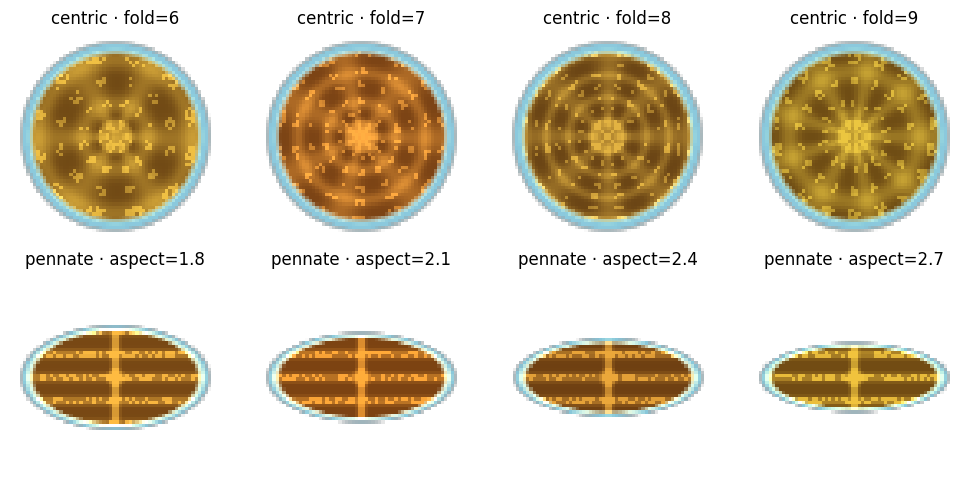

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes[0]):
    ax.imshow(diatom_lib.centric_diatom(size=64, n_fold=6 + i, n_rings=2 + (i % 3), seed=i * 13))
    ax.set_title(f'centric · fold={6 + i}'); ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(diatom_lib.pennate_diatom(size=64, aspect=1.8 + 0.3 * i, seed=100 + i * 7))
    ax.set_title(f'pennate · aspect={1.8 + 0.3 * i:.1f}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. The creature — one local rule, 16 channels per cell

`0:2` RGB · `3` alpha · `4:7` DNA genome · `8:10` morphogen · `11` AUDIO sense · `12:15` hidden/silica. Watch the untrained soup twitch:

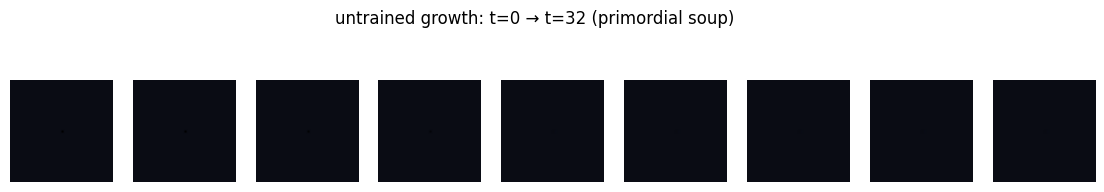

In [ ]:
SIZE = 48
model = DiatomNCA(num_channels=16, hidden_dim=128).to(device)
with torch.no_grad():
    traj = model.grow(32, size=SIZE, device=device)  # (B,T,C,H,W)
frames = [state_to_rgb(s) for s in traj[0, ::4]]
fig, axes = plt.subplots(1, len(frames), figsize=(14, 2.5))
for ax, f in zip(axes, frames):
    ax.imshow(f); ax.axis('off')
plt.suptitle('untrained growth: t=0 → t=32 (primordial soup)'); plt.show()

## 3. Train it — pool + damage (regeneration is learned, not luck)

Short run so it finishes in minutes. For the real creature, raise `steps` to 3000+.

[100/3000] loss=0.07184
[200/3000] loss=0.06377
[300/3000] loss=0.04219
[400/3000] loss=0.05733
[500/3000] loss=0.06032
[600/3000] loss=0.07750
[700/3000] loss=0.05310
[800/3000] loss=0.05075
[900/3000] loss=0.05414
[1000/3000] loss=0.03371
[1100/3000] loss=0.05712
[1200/3000] loss=0.02635
[1300/3000] loss=0.03797
[1400/3000] loss=0.02683
[1500/3000] loss=0.04843
[1600/3000] loss=0.02983
[1700/3000] loss=0.03134
[1800/3000] loss=0.05370
[1900/3000] loss=0.04566
[2000/3000] loss=0.02244
[2100/3000] loss=0.03407
[2200/3000] loss=0.03787
[2300/3000] loss=0.02951
[2400/3000] loss=0.04533
[2500/3000] loss=0.03098
[2600/3000] loss=0.03496
[2700/3000] loss=0.02732
[2800/3000] loss=0.02863
[2900/3000] loss=0.03201
[3000/3000] loss=0.05498


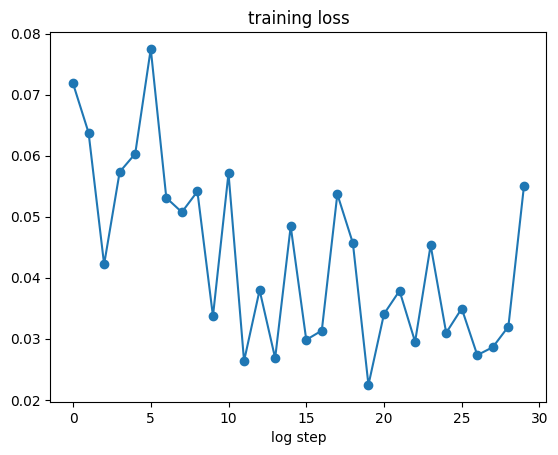

saved diatom_nca.pt — download it from the file browser


In [ ]:
cfg = TrainConfig(size=SIZE, hidden_dim=128, steps=3000, batch=8,
                   pool_size=64, rollout_min=32, rollout_max=64,
                   damage_prob=0.5, audio_prob=0.5, log_every=100, device=device)
losses = []
def on_log(it, loss, sample):
    losses.append(loss); print(f'[{it}/{cfg.steps}] loss={loss:.5f}', flush=True)

train(model, cfg, on_log=on_log)
plt.plot(losses, marker='o'); plt.title('training loss'); plt.xlabel('log step'); plt.show()

torch.save({'state_dict': model.state_dict()}, 'diatom_nca.pt')
print('saved diatom_nca.pt — download it from the file browser')

## 4. Growth timelapse — the trained diatom assembling itself

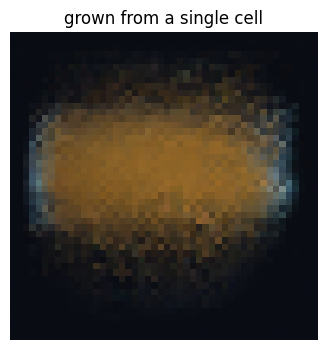

In [ ]:
with torch.no_grad():
    traj = model.grow(96, size=SIZE, device=device)
frames = [state_to_rgb(s) for s in traj[0]]
fig = plt.figure(figsize=(4, 4))
im = plt.imshow(frames[0]); plt.axis('off'); plt.title('grown from a single cell')
HTML(animation.FuncAnimation(fig, lambda i: im.set_data(frames[i]),
     frames=len(frames), interval=60).to_jshtml())

## 5. Surgery — cut it in half. It heals.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


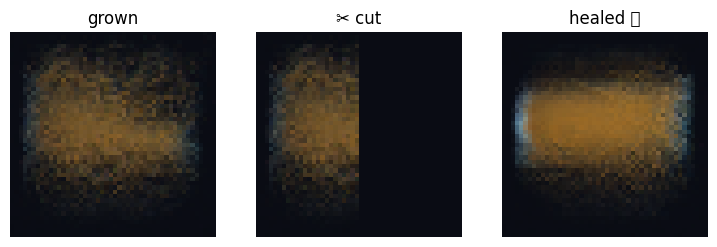

In [ ]:
with torch.no_grad():
    x = model.seed(1, SIZE).to(device)
    x = model(x, steps=64)
    grown = state_to_rgb(x)[0]
    x = half_damage(x)
    cut = state_to_rgb(x)[0]
    x = model(x, steps=64)
    healed = state_to_rgb(x)[0]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, t in zip(axes, [grown, cut, healed], ['grown', '✂️ cut', 'healed ✨']):
    ax.imshow(img); ax.set_title(t); ax.axis('off')
plt.show()

## 6. Sound bends the rule — synth beat drives morphology

8-dim audio vector → FiLM gains retune every neuron + energy scales growth rate. Swap in your own audio by uploading a WAV and using `audio_lib.load_wav()`.

audio frames: (171, 8)


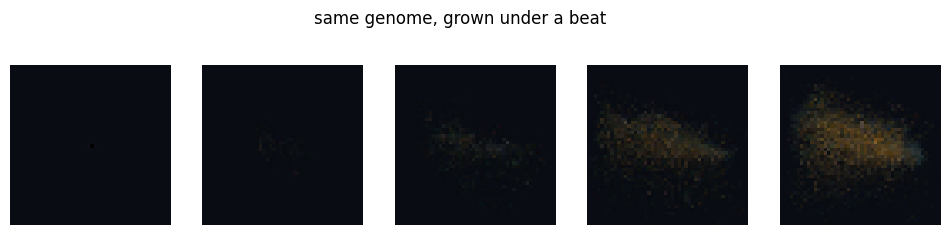

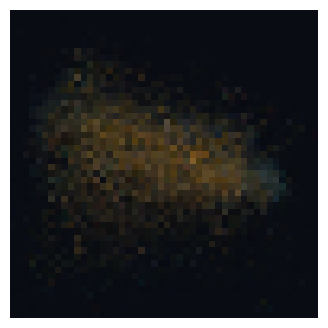

In [ ]:
# from google.colab import files  # ← uncomment to upload your own WAV
# wav_path = list(files.upload().keys())[0]
# wave, sr = audio_lib.load_wav(wav_path)
wave = audio_lib.synth_demo_signal('beat', seconds=4.0)
feats = audio_lib.smooth(audio_lib.stft_features(wave))
print('audio frames:', feats.shape)

STEPS = 96
idx = (np.linspace(0, len(feats) - 1, STEPS)).astype(int)
with torch.no_grad():
    x = model.seed(1, SIZE).to(device)
    seq = []
    for t in range(STEPS):
        a = torch.from_numpy(feats[idx[t]]).unsqueeze(0).to(device)
        energy = float(a[0, 0])
        x = model.update(x, audio=a, fire_rate=0.3 + 0.6 * min(1.0, energy * 3))
        seq.append(state_to_rgb(x)[0])
fig, axes = plt.subplots(1, 5, figsize=(12, 2.8))
for ax, f in zip(axes, [seq[i] for i in np.linspace(0, STEPS - 1, 5, dtype=int)]):
    ax.imshow(f); ax.axis('off')
plt.suptitle('same genome, grown under a beat'); plt.show()

fig = plt.figure(figsize=(4, 4))
im = plt.imshow(seq[0]); plt.axis('off')
HTML(animation.FuncAnimation(fig, lambda i: im.set_data(seq[i]), frames=len(seq), interval=60).to_jshtml())

## 7. It talks — the creature sings its growth

Mass becomes pentatonic pitch, pigment becomes chord, growth becomes loudness. Listen, then play the song back and watch it grow under its own voice.

song: 14.5s stereo


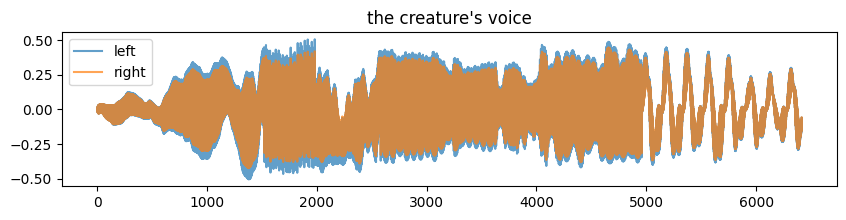

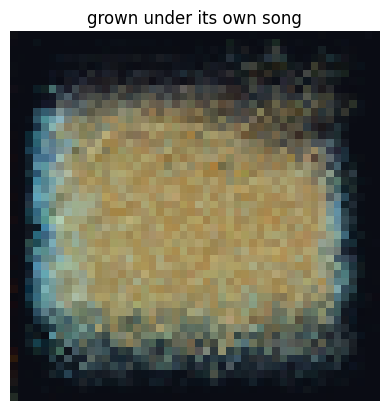

In [ ]:
from nca.voice import sing
from IPython.display import Audio

with torch.no_grad():
    song_traj = model.grow(96, size=SIZE, device=device)
song = sing(song_traj[0])
print(f'song: {len(song)/22050:.1f}s stereo')
Audio(song.T, rate=22050)

plt.figure(figsize=(10, 2))
plt.plot(song[::50, 0], alpha=0.7, label='left')
plt.plot(song[::50, 1], alpha=0.7, label='right')
plt.title("the creature's voice"); plt.legend(); plt.show()

# Self-listening: grow a twin under the song
feats2 = audio_lib.smooth(audio_lib.stft_features(song.mean(axis=1).astype(np.float32)))
idx2 = (np.linspace(0, len(feats2) - 1, 64)).astype(int)
with torch.no_grad():
    x = model.seed(1, SIZE).to(device)
    for t in range(64):
        a = torch.from_numpy(feats2[idx2[t]]).unsqueeze(0).to(device)
        x = model.update(x, audio=a)
    twin = state_to_rgb(x)[0]
plt.imshow(twin); plt.axis('off'); plt.title('grown under its own song'); plt.show()

## 8. New species — mutate the DNA channels

Same rule, different genome → different frustule.

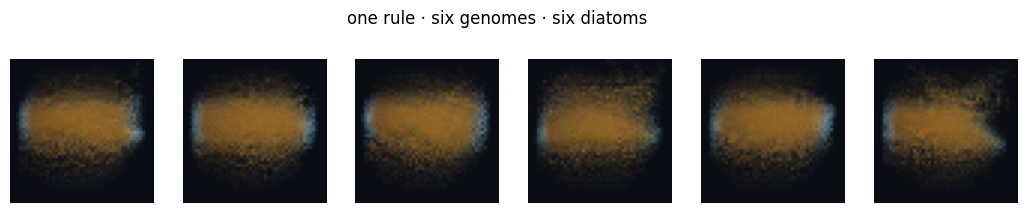

In [ ]:
with torch.no_grad():
    genomes = torch.randn(6, 4) * 0.5
    species = []
    for g in genomes:
        x = model.seed(1, SIZE, device=device, genome=g.unsqueeze(0))
        species.append(state_to_rgb(model(x, steps=96))[0])
fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))
for ax, s in zip(axes, species):
    ax.imshow(s); ax.axis('off')
plt.suptitle('one rule · six genomes · six diatoms'); plt.show()

## 9. It speaks — eyes, instinct, backbone, persona

The talking-NCA stack: the visual module reads the body, the RID instinct layer feels it, a language backbone narrates it, a persona styles it — and the words feed back into growth. Three personas, one wound.

In [ ]:
from nca.mind import DiatomMind
from nca.utils import half_damage

for persona in ['diatom_elder', 'lab_assistant', 'feral_bloom']:
    mind = DiatomMind(model, persona=persona, seed=0)
    out = mind.run(48, size=SIZE, speak_every=24)
    print(f'── {persona} ──')
    for line in out['transcript']:
        print(f"[t={line['step']}] {line['said']}")
    with torch.no_grad():
        x = half_damage(out['final'])
        print('[wounded]', mind.utter(mind.observe(x)))
    print()

── diatom_elder ──
[t=24] Currents pull at my valves. My glass holds against the sea. I am small, blooming, whole, whole-ringed. So it is.
[t=48] I drift in the blue. My glass holds against the sea. I am grown, blooming, whole, whole-ringed.
[wounded] From the silica deep: I drift in the blue. Something tore my frustule. Body: small, shrinking, wounded, awhole-ringed.

── lab_assistant ──
[t=24] Specimen nominal. Structural integrity nominal. I am small, growing, whole, symmetric.
[t=48] Log: Specimen nominal. Structural integrity nominal. I am grown, growing, whole, symmetric.
[wounded] Specimen nominal. Damage event recorded. Body: small, shrinking, wounded, asymmetric.

── feral_bloom ──
[t=24] *bloom-static* Drift drift drift. Glass strong. Shine! I am small, growing, whole, symmetric.
[t=48] Drift drift drift. Glass strong. Shine! I am grown, growing, whole, symmetric.
[wounded] *bloom-static* Drift drift drift. Torn! Torn! Seal it! Body: small, shrinking, wounded, asymmetric.



## Next dives

- Section 3 is the 3000-step run. Sections 11–12 score healing and latent prediction.
- `scripts/export_weights.py` → drop `weights.json` next to `web/demo.html` for the live mic creature.
- Song → species: average a track's features into one vector, inject it as the genome, grow the album cover.

## 10. Song → species — average a track's features into one vector, inject it as the genome, grow the album cover

Generated genome from song features (first 4 dimensions): [0.5874146  0.04337138 0.02898149 0.34287587]


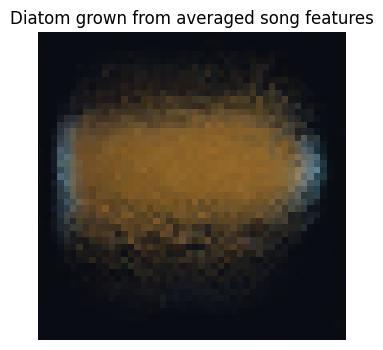

In [ ]:
import sys
import os
if not os.path.exists('/content/Automata'):
    import subprocess
    subprocess.run(['git', 'clone', '-q', 'https://github.com/AaronGrace978/Automata.git', '/content/Automata'])
if '/content/Automata' not in sys.path:
    sys.path.insert(0, '/content/Automata')

import torch
import numpy as np
import matplotlib.pyplot as plt
from nca.voice import sing
from nca import audio as audio_lib
from nca.utils import state_to_rgb

if 'model' in locals() or 'model' in globals():
    # Ensure the model and its perception kernel are on the correct device to avoid device mismatch errors
    model.to(device)
    if hasattr(model, 'perception_kernel'):
        model.perception_kernel = model.perception_kernel.to(device)

    with torch.no_grad():
        # First, let's generate a song from a grown diatom, similar to section 7
        song_traj_for_genome = model.grow(96, size=SIZE, device=device)
        generated_song = sing(song_traj_for_genome[0])

    # Extract STFT features from the generated song
    # Using the mean of the stereo channels for feature extraction
    feats_for_genome = audio_lib.smooth(audio_lib.stft_features(generated_song.mean(axis=1).astype(np.float32)))

    # Average the features to create a single genome vector
    # The genome in DiatomNCA is 4-dimensional, so we'll take the first 4 averaged features.
    average_genome_vector = torch.from_numpy(feats_for_genome.mean(axis=0)[:4]).float()

    # If the `average_genome_vector` is shorter than 4, pad it with zeros
    if average_genome_vector.shape[0] < 4:
        padded_genome_vector = torch.zeros(4, dtype=torch.float32)
        padded_genome_vector[:average_genome_vector.shape[0]] = average_genome_vector
        average_genome_vector = padded_genome_vector

    print(f"Generated genome from song features (first 4 dimensions): {average_genome_vector.numpy()}")

    # Now, grow a new diatom using this averaged feature vector as its genome
    with torch.no_grad():
        # Ensure genome is 1x4 (batch_size, genome_dim)
        genome_for_new_species = average_genome_vector.unsqueeze(0).to(device)

        x_new_species = model.seed(1, SIZE, device=device, genome=genome_for_new_species)
        grown_from_song_genome = state_to_rgb(model(x_new_species, steps=96))[0]

    # Display the resulting diatom
    plt.figure(figsize=(4, 4))
    plt.imshow(grown_from_song_genome)
    plt.axis('off')
    plt.title('Diatom grown from averaged song features')
    plt.show()
else:
    print("Please run the setup and model initialization cells (Sections 0 to 4) first to define `model`, `SIZE`, and `device`.")

## 11. Regeneration score

Overlap of alive cells in the cut half, healed versus an uncut twin. The GIF shows healing; this number measures it.

regeneration IoU (cut half): 0.923


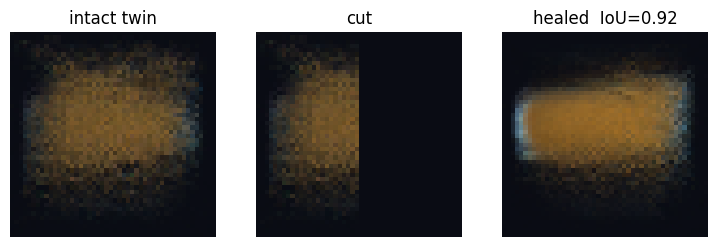

In [24]:
import torch
from nca.utils import half_damage

def regeneration_iou(healed, intact, alpha=3, thresh=0.1):
    if healed.dim() == 3:
        healed, intact = healed.unsqueeze(0), intact.unsqueeze(0)
    h = healed[:, alpha] > thresh
    i = intact[:, alpha] > thresh
    half = h.shape[-1] // 2
    h, i = h[..., half:], i[..., half:]
    inter = (h & i).sum().float()
    union = (h | i).sum().float().clamp(min=1)
    return float(inter / union)

model.to(device)
with torch.no_grad():
    twin = model(model.seed(1, SIZE, device=device), steps=64)
    cut = half_damage(twin.clone())
    healed = model(cut, steps=64)
score = regeneration_iou(healed, twin)
print(f'regeneration IoU (cut half): {score:.3f}')
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, t in zip(axes, [twin, cut, healed], ['intact twin', 'cut', f'healed  IoU={score:.2f}']):
    ax.imshow(state_to_rgb(img)[0]); ax.set_title(t); ax.axis('off')
plt.show()


## 12. JEPA step — predict the body, not the pixels

Mask the right half. A tiny predictor learns the *embedding* of the whole creature from the embedding of the wounded one. Latent prediction, on this substrate.

cosine  step 1: 0.097   step 40: 0.999


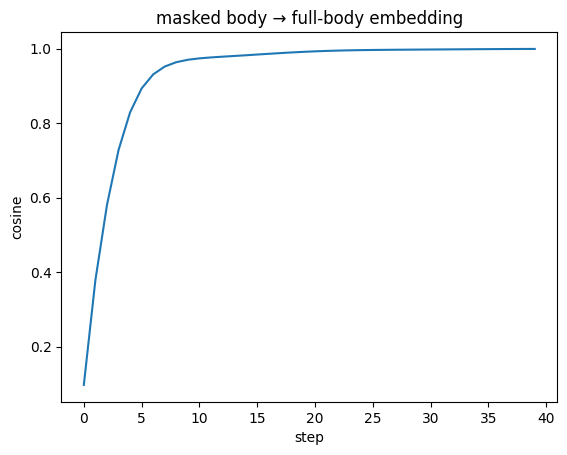

In [25]:
import torch
import torch.nn.functional as F
from nca.vision import VisualEncoder

class LatentPredictor(torch.nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        self.net = torch.nn.Sequential(torch.nn.Linear(dim, dim), torch.nn.ReLU(), torch.nn.Linear(dim, dim))
    def forward(self, z):
        return self.net(z)

def jepa_step(encoder, predictor, opt, x):
    with torch.no_grad():
        target = encoder(x)
        masked = x.clone(); masked[..., masked.shape[-1] // 2:] = 0
        masked = encoder(masked)
    pred = predictor(masked)
    loss = 1 - F.cosine_similarity(pred, target.detach(), dim=-1).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    return float(1 - loss.detach())

encoder = VisualEncoder().to(device)
predictor = LatentPredictor().to(device)
opt = torch.optim.Adam(predictor.parameters(), lr=1e-2)
batch = torch.rand(8, 16, SIZE, SIZE, device=device)
cosines = [jepa_step(encoder, predictor, opt, batch) for _ in range(40)]
print(f'cosine  step 1: {cosines[0]:.3f}   step 40: {cosines[-1]:.3f}')
plt.plot(cosines); plt.title('masked body → full-body embedding'); plt.xlabel('step'); plt.ylabel('cosine'); plt.show()
